In [1]:
import os, torch
print("Logical cores:", os.cpu_count())
print("Torch threads:", torch.get_num_threads())

Logical cores: 20
Torch threads: 14


In [2]:
import os
import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

torch.set_num_threads(20)
torch.set_num_interop_threads(20)

device = "cpu"
dtype = torch.float32

from diffusers import StableDiffusionPipeline, UniPCMultistepScheduler
from IPython.display import display
from PIL import Image

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# Force default (non-sliced) attention processors
pipe.unet.set_default_attn_processor()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/16 [00:00<?, ?it/s]

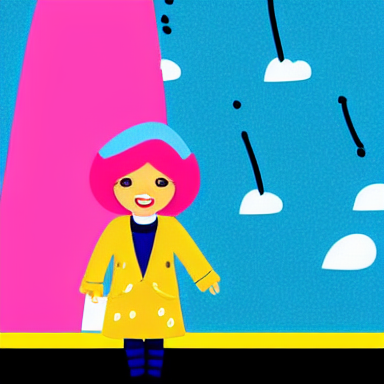

In [4]:
WIDTH, HEIGHT = 384, 384
STEPS_REF = 16
GUIDANCE_REF = 6.5

BASE_STYLE = "stylized animated film, soft lighting, clean shapes, cinematic"
NEGATIVE = "photorealistic, hyper-detailed, blurry, distorted, text, watermark"

REF_PROMPT = (
    "full body, standing, facing camera, neutral pose. "
    "8 year old girl, short brown bob haircut, freckles, yellow raincoat, blue rain boots."
)

ref_image = pipe(
    prompt=f"{REF_PROMPT}. {BASE_STYLE}",
    negative_prompt=NEGATIVE,
    width=WIDTH,
    height=HEIGHT,
    num_inference_steps=STEPS_REF,
    guidance_scale=GUIDANCE_REF,
    generator=torch.Generator(device=device).manual_seed(123),
).images[0]

display(ref_image)

In [5]:
# Force default processors RIGHT BEFORE loading the adapter
pipe.unet.set_default_attn_processor()

pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="models",
    weight_name="ip-adapter_sd15.safetensors",
)

pipe.set_ip_adapter_scale(0.85)

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating scene 1...


  0%|          | 0/16 [00:00<?, ?it/s]

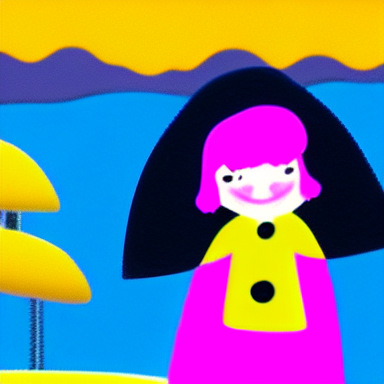

Generating scene 2...


  0%|          | 0/16 [00:00<?, ?it/s]

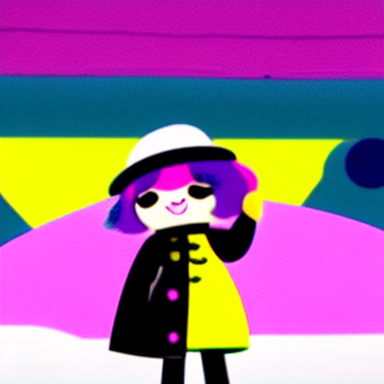

Generating scene 3...


  0%|          | 0/16 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
scene_prompts = [
    "wide shot, walking alone across an empty field, no flower visible",
    "medium shot, kneeling to examine a small flower in the grass",
    "close shot, gently holding the flower, warm expression",
    "side profile, walking onward with the flower tucked into her coat pocket, hopeful mood",
]

STEPS = 16
GUIDANCE = 6.5

generated_images = []

for i, scene in enumerate(scene_prompts, 1):
    print(f"Generating scene {i}...")

    img = pipe(
        prompt=f"{scene}. {BASE_STYLE}",
        negative_prompt=NEGATIVE,
        ip_adapter_image=ref_image,
        width=WIDTH,
        height=HEIGHT,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=torch.Generator(device=device).manual_seed(1000 + i),
    ).images[0]

    generated_images.append(img)
    display(img)

In [ ]:
import os
from PIL import Image
from IPython.display import display

output_dir = os.path.join(os.getcwd(), "ip_adapter_storyboard")
os.makedirs(output_dir, exist_ok=True)

for i, img in enumerate(generated_images, 1):
    img.save(os.path.join(output_dir, f"scene_{i}.png"))

w, h = generated_images[0].size
storyboard = Image.new("RGB", (w * 2, h * 2))
storyboard.paste(generated_images[0], (0, 0))
storyboard.paste(generated_images[1], (w, 0))
storyboard.paste(generated_images[2], (0, h))
storyboard.paste(generated_images[3], (w, h))

storyboard.save(os.path.join(output_dir, "storyboard_2x2.png"))
display(storyboard)